## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr

wr.filterwarnings('ignore')

## 2. Reading Dataset

In [2]:
df=pd.read_csv('customer_shopping_behavior.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 3.Analyzing the Data

In [3]:
#shape of the dataset
df.shape

(3900, 18)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,1950.500000,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,44.068462,15.207589,18.0,31.00,44.0,57.00,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.00,60.0,81.00,100.0
Review Rating,3863.0,3.750065,0.716983,2.5,3.10,3.8,4.40,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.00,25.0,38.00,50.0


In [6]:
df.columns.tolist()

['Customer ID',
 'Age',
 'Gender',
 'Item Purchased',
 'Category',
 'Purchase Amount (USD)',
 'Location',
 'Size',
 'Color',
 'Season',
 'Review Rating',
 'Subscription Status',
 'Shipping Type',
 'Discount Applied',
 'Promo Code Used',
 'Previous Purchases',
 'Payment Method',
 'Frequency of Purchases']

## 4.Checking Missing Values

In [7]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [8]:
# Fill missing values with median
df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].median())
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

## 5.Checking for the duplicate values

In [9]:
df.duplicated().sum()

np.int64(0)

## 6.Univariate Analysis

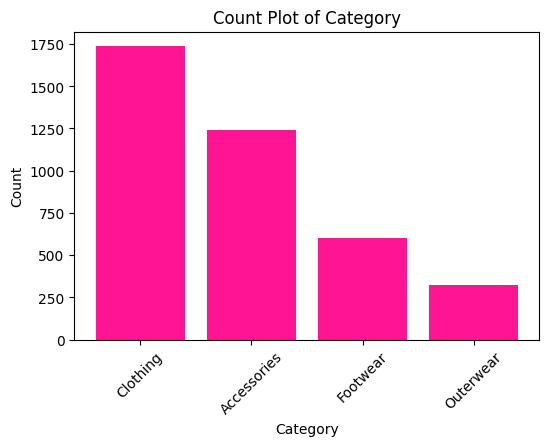

In [10]:
# 1. Bar Plot
category_counts = df['Category'].value_counts()

plt.figure(figsize=(6,4))

plt.bar(category_counts.index,
        category_counts.values,
        color='deeppink')

plt.title('Count Plot of Category')
plt.xlabel('Category')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

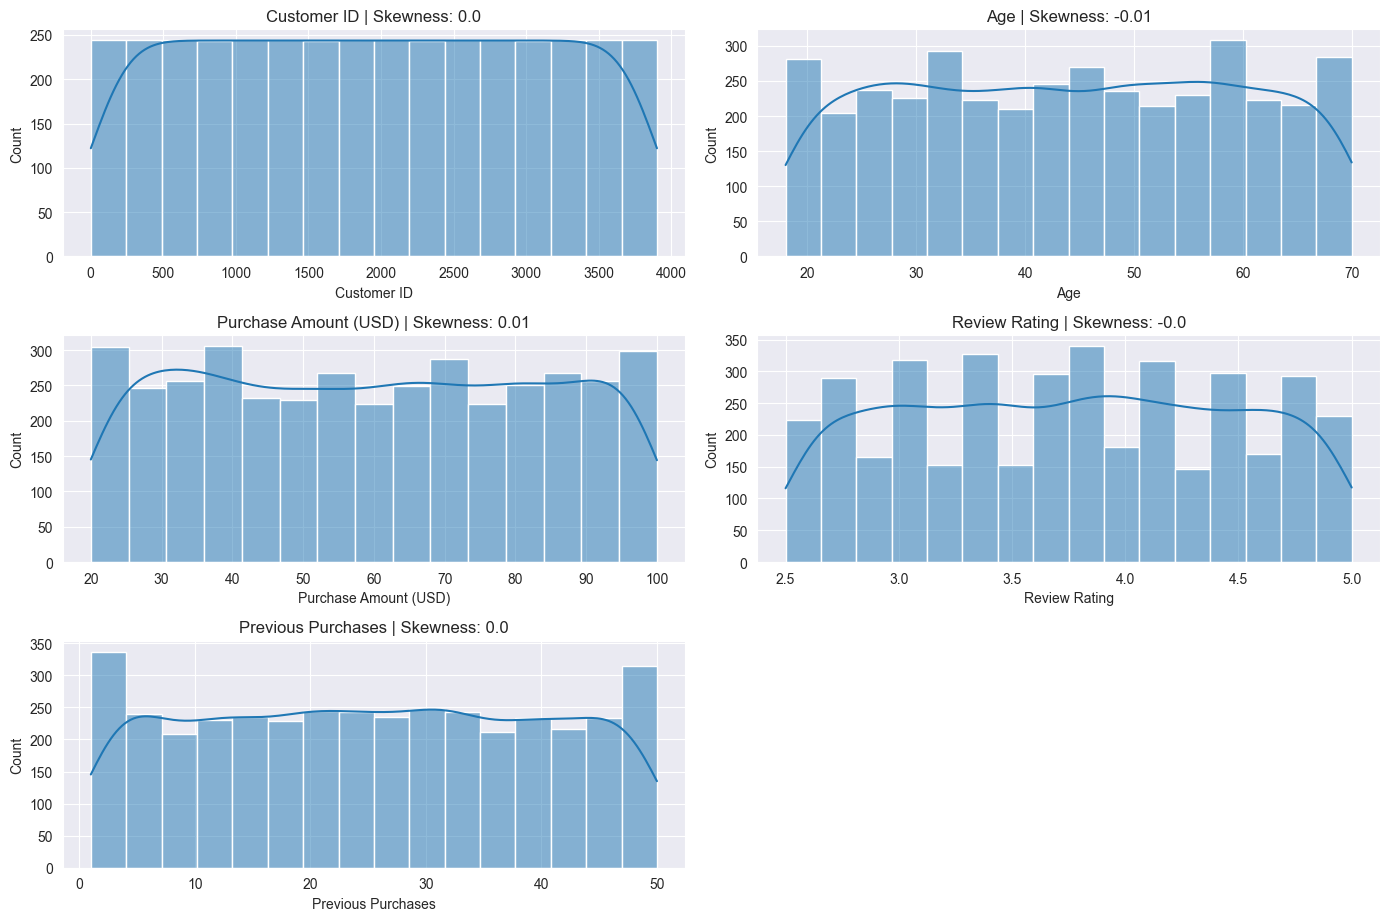

In [11]:
# 2. Histogram + KDE Plot
sns.set_style("darkgrid")
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(14, len(numerical_columns)*3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(
        f"{feature} | Skewness: {round(df[feature].skew(),2)}"
    )

plt.tight_layout()
plt.show()

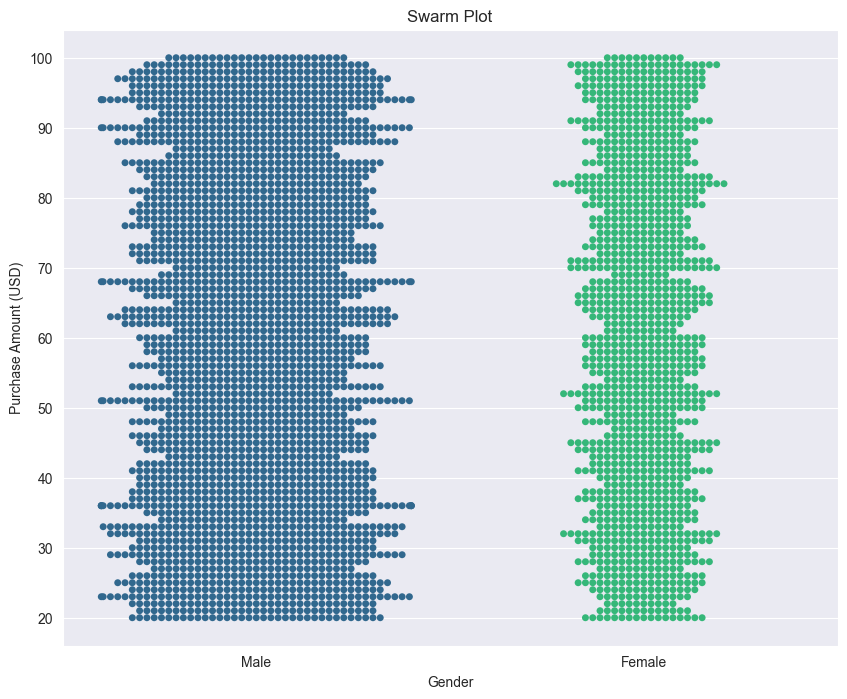

In [12]:
# 3. Swarm Plot
plt.figure(figsize=(10,8))

sns.swarmplot(
    x="Gender",
    y="Purchase Amount (USD)",
    data=df,
    palette='viridis'
)

plt.title('Swarm Plot')

plt.xlabel('Gender')
plt.ylabel('Purchase Amount (USD)')

plt.show()

## 7.Bivariate Analysis

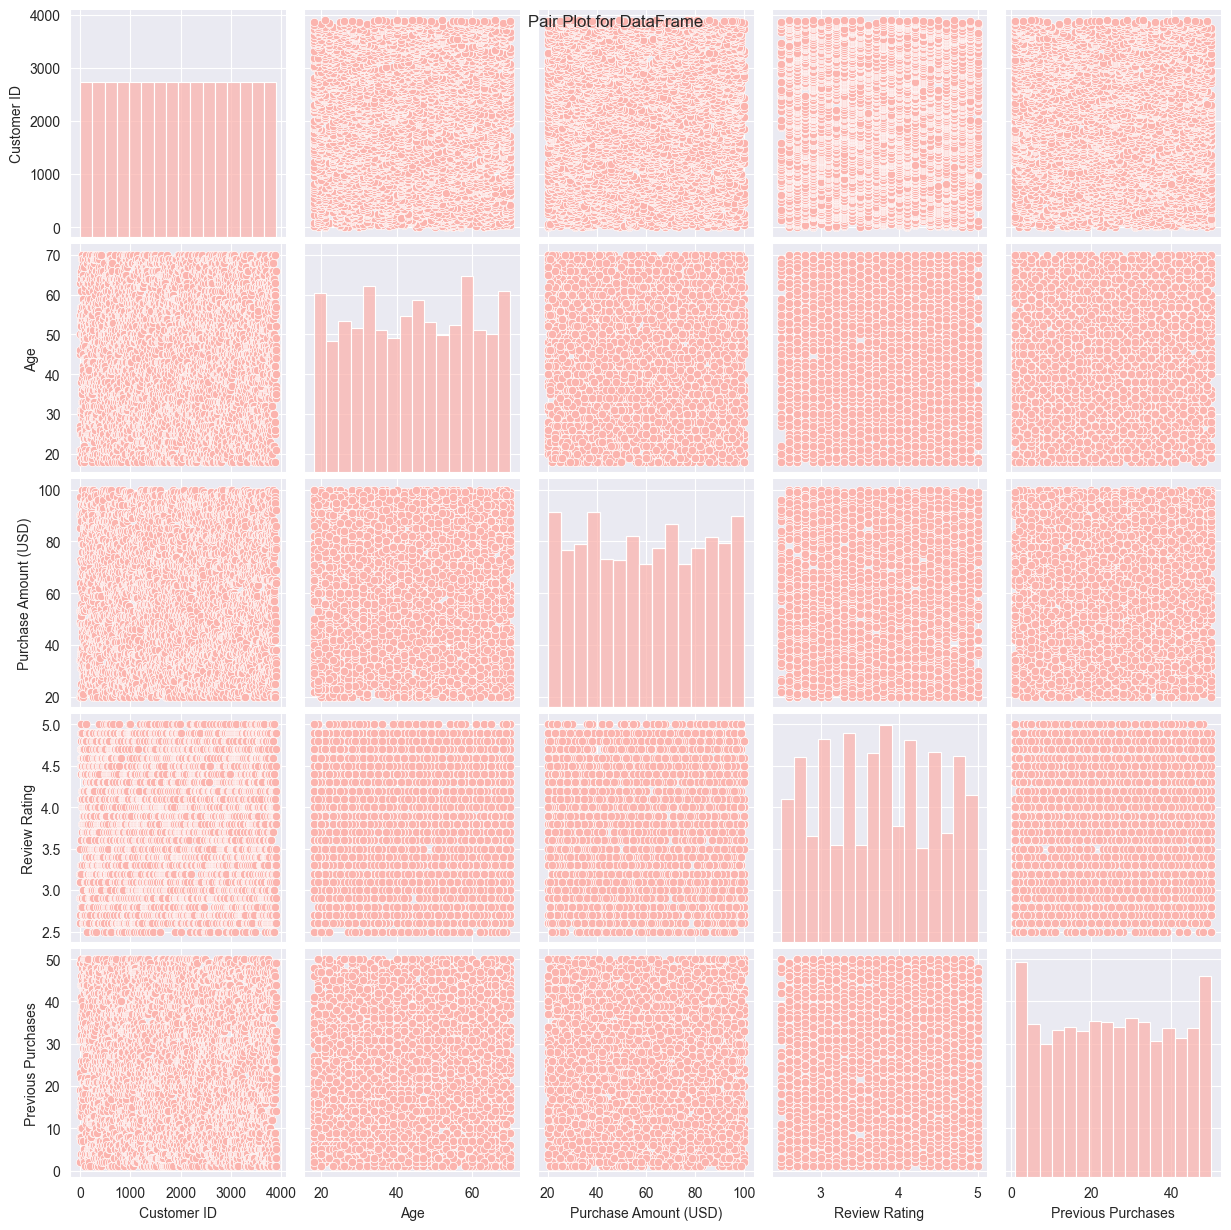

In [13]:
# 1. Pair Plot
sns.set_palette("Pastel1")
sns.pairplot(df)
plt.suptitle('Pair Plot for DataFrame')
plt.show()

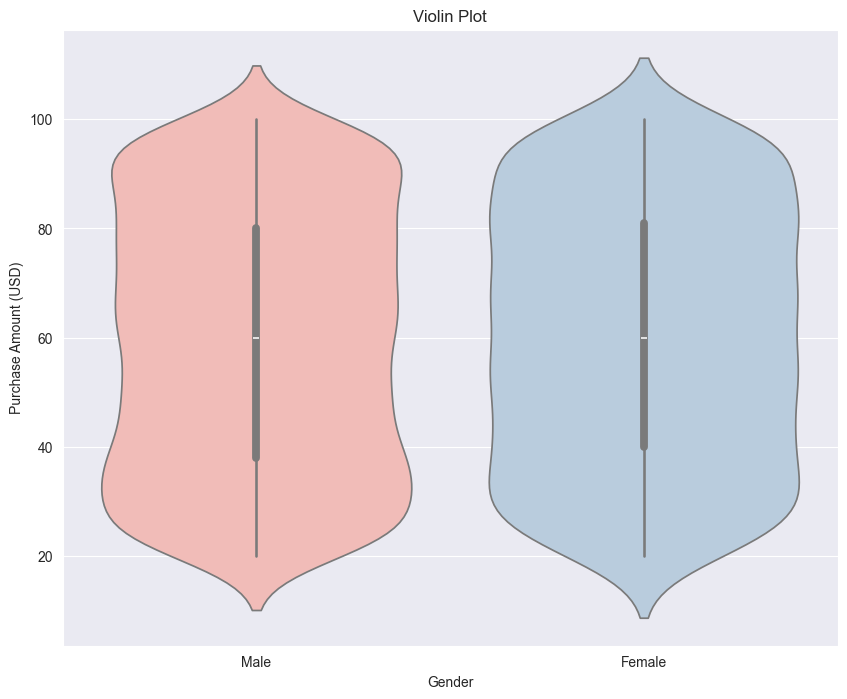

In [14]:
# 2. Violin Plot
plt.figure(figsize=(10,8))
sns.violinplot(
    x="Gender",
    y="Purchase Amount (USD)",
    data=df,
    palette='Pastel1'
)
plt.title('Violin Plot')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount (USD)')
plt.show()

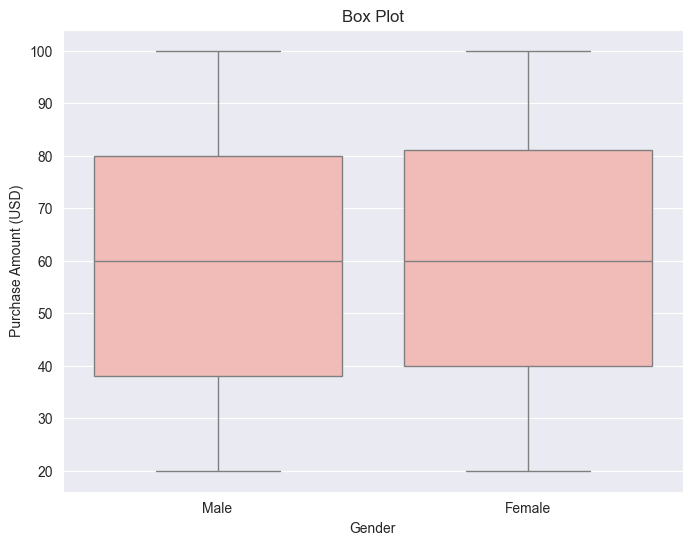

In [15]:
# 3. Box Plot
plt.figure(figsize=(8,6))
sns.boxplot(x='Gender', y='Purchase Amount (USD)',data=df)
plt.title('Box Plot')
plt.show()

## 8.Multivariate Analysis

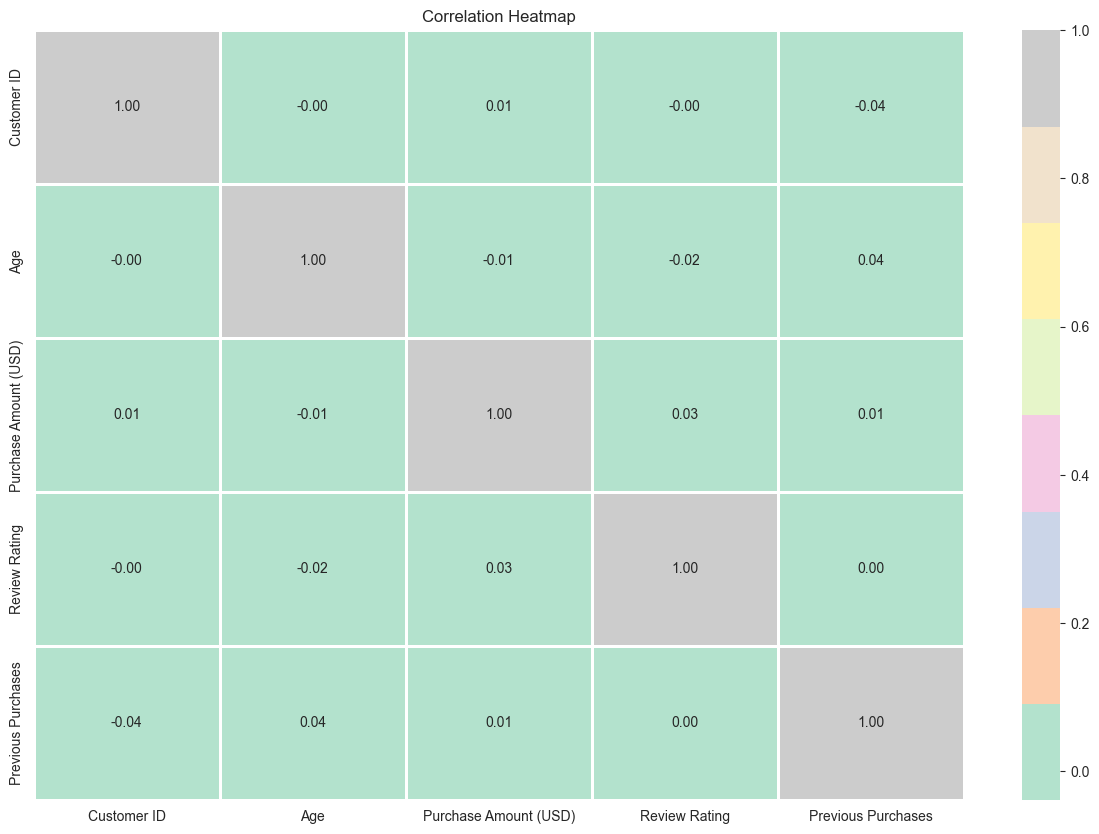

In [16]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='Pastel2',linewidths=2)
plt.title('Correlation Heatmap')
plt.show()